<a href="https://colab.research.google.com/github/aristidekanamugire/Titanic-data-cleaning/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Titanic Data Munging and Cleaning**

Task 1: Loading & Inspecting

In [ ]:
# Task 1: Load & Inspect Titanic Dataset

import pandas as pd

# Load from Google Drive path
data_path = "/content/drive/MyDrive/titanic.csv"
df = pd.read_csv(data_path)

# Display first 10 rows
print("First 10 rows:")
display(df.head(10).style.set_caption("**First 10 Rows of Titanic Dataset**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))

# Info summary
print("\nDataFrame Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe().style.set_caption("**Statistical Summary**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))

# Missing values count
print("\nMissing values in each column:")
missing_table = df.isnull().sum().to_frame("Missing Count")
display(missing_table.style.set_caption("**Missing Values Per Column**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))



First 10 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,nan,S
5,6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.458300,nan,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.862500,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.075000,nan,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.133300,nan,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.070800,nan,C



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing values in each column:


,Missing Count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Task 2 — Missing Data Imputation

In [ ]:
# Task 2: Handle Missing Data

import numpy as np

# % missing for Age
age_missing_pct = df['Age'].isnull().mean() * 100
print(f"Missing Age Percentage: {age_missing_pct:.2f}%")

# Impute Age by median grouped by Pclass and Sex (only if missing exists)
if df['Age'].isnull().sum() > 0:
    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

# Fill Embarked with mode if missing exists
if df['Embarked'].isnull().sum() > 0:
    embarked_mode = df['Embarked'].mode()[0]
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Drop Cabin if exists
df = df.drop(columns=['Cabin'], errors='ignore')

print("\nMissing values after imputation:")
missing_table = df.isnull().sum().to_frame("Missing Count")
display(missing_table.style.set_caption("**Missing Values After Imputation**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))


Missing Age Percentage: 19.87%

Missing values after imputation:


,Missing Count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Task 3 — Outlier Detection & Treatment

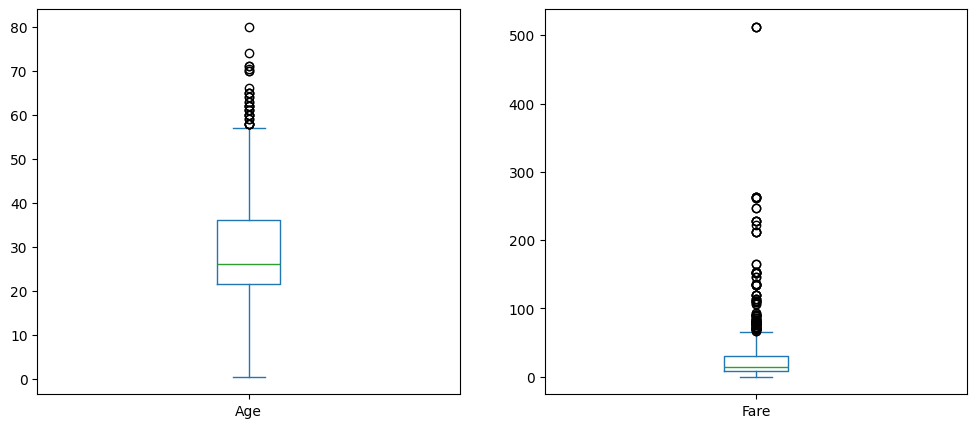

,Outlier Count
Age,33
Fare,116


In [ ]:
# Task 3: Outlier Detection for Age and Fare

import matplotlib.pyplot as plt

# Boxplots
df[['Age', 'Fare']].plot(kind='box', subplots=True, layout=(1,2), figsize=(12,5))
plt.show()

# Compute IQR bounds
def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

outlier_counts = {}
for col in ['Age', 'Fare']:
    low, high = iqr_bounds(df[col])
    outliers = df[(df[col] < low) | (df[col] > high)]
    outlier_counts[col] = len(outliers)

    # Treat outliers by capping
    lower_cap = df[col].quantile(0.01)
    upper_cap = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower_cap, upper_cap)

# Show outlier counts table
outlier_table = pd.DataFrame.from_dict(outlier_counts, orient="index", columns=["Outlier Count"])
display(outlier_table.style.set_caption("**Detected Outliers Before Treatment**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))


Task 4 — Data Compatibility & Unification

In [ ]:
# Task 4: Feature Unification & Encoding

# Extract Titles
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Other')

# Convert categorical columns
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

# Rename columns
df.columns = df.columns.str.lower().str.replace(' ', '_')

# One-hot encode categorical
df = pd.get_dummies(df, columns=['sex', 'embarked', 'title'], drop_first=True)

display(df.head(10).style.set_caption("**DataFrame After Encoding**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-3553999287.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,passengerid,survived,pclass,name,age,sibsp,parch,ticket,fare,sex_male,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_Other
0,1,0,3,"Braund, Mr. Owen Harris",22.000000,1,0,A/5 21171,7.250000,True,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.000000,1,0,PC 17599,71.283300,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.000000,0,0,STON/O2. 3101282,7.925000,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,1,0,113803,53.100000,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.000000,0,0,373450,8.050000,True,False,True,False,True,False,False
5,6,0,3,"Moran, Mr. James",25.000000,0,0,330877,8.458300,True,True,False,False,True,False,False
6,7,0,1,"McCarthy, Mr. Timothy J",54.000000,0,0,17463,51.862500,True,False,True,False,True,False,False
7,8,0,3,"Palsson, Master. Gosta Leonard",2.000000,3,1,349909,21.075000,True,False,True,False,False,False,False
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.000000,0,2,347742,11.133300,False,False,True,False,False,True,False
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",14.000000,1,0,237736,30.070800,False,False,False,False,False,True,False


Task 5 — Normalization and Z-Scores

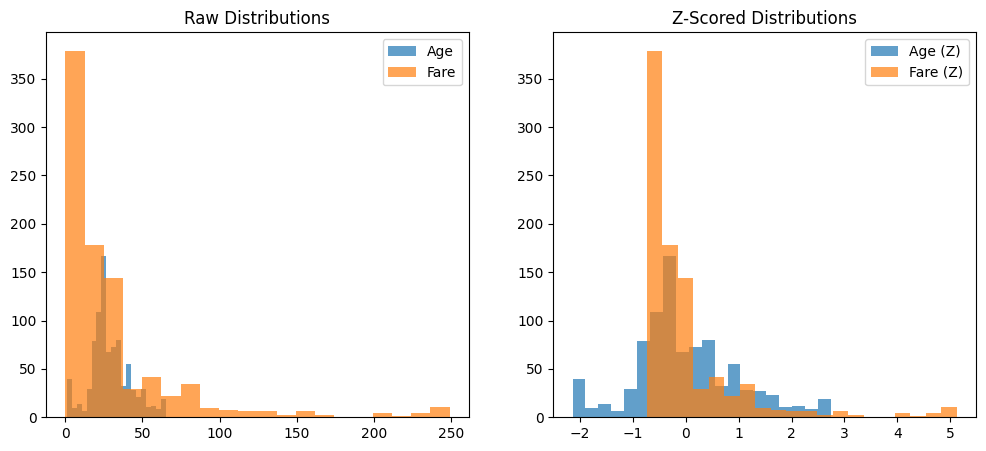

,age,fare,age_z,fare_z
0,22.000000,7.250000,-0.538067,-0.564109
1,38.000000,71.283300,0.682117,0.942548
2,26.000000,7.925000,-0.233021,-0.548227
3,35.000000,53.100000,0.453332,0.514708
4,35.000000,8.050000,0.453332,-0.545285
5,25.000000,8.458300,-0.309283,-0.535678
6,54.000000,51.862500,1.902300,0.485591
7,2.000000,21.075000,-2.063297,-0.238817
8,27.000000,11.133300,-0.156760,-0.472738
9,14.000000,30.070800,-1.148159,-0.027152


In [ ]:
# Task 5: Normalization with Z-Scores

from scipy.stats import zscore
import numpy as np

def safe_zscore(series):
    if series.std() == 0 or series.isnull().all():
        return pd.Series([0]*len(series), index=series.index)  # fallback to 0
    return zscore(series)

# Compute z-scores safely
if 'age' in df.columns:
    df['age_z'] = safe_zscore(df['age'])
if 'fare' in df.columns:
    df['fare_z'] = safe_zscore(df['fare'])

# Compare histograms only if data exists
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Raw distributions
if 'age' in df.columns and not df['age'].isnull().all():
    axes[0].hist(df['age'].dropna(), bins=20, alpha=0.7, label="Age")
if 'fare' in df.columns and not df['fare'].isnull().all():
    axes[0].hist(df['fare'].dropna(), bins=20, alpha=0.7, label="Fare")
axes[0].set_title("Raw Distributions")
axes[0].legend()

# Z-scored distributions
if 'age_z' in df.columns and not df['age_z'].isnull().all():
    axes[1].hist(df['age_z'].dropna(), bins=20, alpha=0.7, label="Age (Z)")
if 'fare_z' in df.columns and not df['fare_z'].isnull().all():
    axes[1].hist(df['fare_z'].dropna(), bins=20, alpha=0.7, label="Fare (Z)")
axes[1].set_title("Z-Scored Distributions")
axes[1].legend()

plt.show()

# Show a bold sample comparison table
z_table = df[['age', 'fare', 'age_z', 'fare_z']].head(10)
display(z_table.style.set_caption("**Sample of Raw vs. Z-Scored Values (Fixed)**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))


Task 6 — Reproducible Cleaning Pipeline

In [ ]:
# Task 6: Cleaning Pipeline

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class TitanicCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Age imputation
        if df['Age'].isnull().sum() > 0:
            df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
                lambda x: x.fillna(x.median())
            )

        # Embarked imputation
        if df['Embarked'].isnull().sum() > 0:
            df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

        # Drop Cabin safely
        df = df.drop(columns=['Cabin'], errors='ignore')

        # Titles
        df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
        df['Title'] = df['Title'].replace(rare_titles, 'Other')

        # Rename columns
        df.columns = df.columns.str.lower().str.replace(' ', '_')

        # One-hot encode
        df = pd.get_dummies(df, columns=['sex', 'embarked', 'title'], drop_first=True)

        # Cap outliers
        for col in ['age', 'fare']:
            if col in df.columns:
                lower_cap = df[col].quantile(0.01)
                upper_cap = df[col].quantile(0.99)
                df[col] = np.clip(df[col], lower_cap, upper_cap)

        # Add z-scores
        if 'age' in df.columns: df['age_z'] = zscore(df['age'])
        if 'fare' in df.columns: df['fare_z'] = zscore(df['fare'])

        return df

# Run pipeline
pipeline = Pipeline([
    ('cleaner', TitanicCleaner())
])

cleaned_df = pipeline.fit_transform(pd.read_csv(data_path))

# Export cleaned dataset
cleaned_df.to_csv("/content/drive/MyDrive/cleaned_titanic.csv", index=False)
print(" Cleaned data saved as cleaned_titanic.csv")

display(cleaned_df.head(10).style.set_caption("**Final Cleaned Titanic Data**").set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))


 Cleaned data saved as cleaned_titanic.csv


<>:27: SyntaxWarning: invalid escape sequence '\.'
<>:27: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-962423923.py:27: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,passengerid,survived,pclass,name,age,sibsp,parch,ticket,fare,sex_male,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_Other,age_z,fare_z
0,1,0,3,"Braund, Mr. Owen Harris",22.000000,1,0,A/5 21171,7.250000,True,False,True,False,True,False,False,-0.538067,-0.564109
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.000000,1,0,PC 17599,71.283300,False,False,False,False,False,True,False,0.682117,0.942548
2,3,1,3,"Heikkinen, Miss. Laina",26.000000,0,0,STON/O2. 3101282,7.925000,False,False,True,True,False,False,False,-0.233021,-0.548227
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,1,0,113803,53.100000,False,False,True,False,False,True,False,0.453332,0.514708
4,5,0,3,"Allen, Mr. William Henry",35.000000,0,0,373450,8.050000,True,False,True,False,True,False,False,0.453332,-0.545285
5,6,0,3,"Moran, Mr. James",25.000000,0,0,330877,8.458300,True,True,False,False,True,False,False,-0.309283,-0.535678
6,7,0,1,"McCarthy, Mr. Timothy J",54.000000,0,0,17463,51.862500,True,False,True,False,True,False,False,1.902300,0.485591
7,8,0,3,"Palsson, Master. Gosta Leonard",2.000000,3,1,349909,21.075000,True,False,True,False,False,False,False,-2.063297,-0.238817
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.000000,0,2,347742,11.133300,False,False,True,False,False,True,False,-0.156760,-0.472738
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",14.000000,1,0,237736,30.070800,False,False,False,False,False,True,False,-1.148159,-0.027152
